In [10]:
# Importar bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os
from pathlib import Path

sys.path.append(os.path.abspath('..'))

# importar funções úteis do módulo de preprocessing
from src.preprocessing import *
from src.feature_engineering import *
from src.train import *
from src.utils import *
from src.evaluate import *
from src.feature_selection import *

In [11]:
#Parâmetros globais
target_col = "DEFASADO"
vars_fe = ["DEFASADO", "DEFASAGEM", "ANO_BASE", "ALTO_INDE", "INDE"]

In [12]:
# Carregar o arquivo Excel
file_path = r'C:\Users\pedro\OneDrive\1- ESTUDO\2- FIAP\1- POS TECH MACHINE LEARNING\F5\MLET_FASE5_DATATHON\Base_pede.xlsx'

# Carregar os dados de cada ano
df_2022 = pd.read_excel(file_path, sheet_name='PEDE2022')
df_2023 = pd.read_excel(file_path, sheet_name='PEDE2023')
df_2024 = pd.read_excel(file_path, sheet_name='PEDE2024')

# Padronizar colunas
df22 = padronizar_colunas(df_2022, column_mapping, year=2022, return_summary=False)
df23 = padronizar_colunas(df_2023, column_mapping, year=2023, return_summary=False)
df24 = padronizar_colunas(df_2024, column_mapping, year=2024, return_summary=False)

# Concatenar dataframes
df_concat = pd.concat([df22, df23, df24], ignore_index=True)

# Aplicar correção de idade e enforcer de schema
df_fix_idade = fix_idade(df_concat)
df_schema, schema_errors = enforce_schema(df_fix_idade, schema= EXPECTED_SCHEMA)

#Separa as colunas numéricas e categóricas para as próximas etapas
numeric_cols, categorical_cols = split_feature_types(
    df_schema,
    target_col=target_col
)

#Tratamento de missings
df_pede, missing_summary = handle_missing_values(
    df_schema,
    numeric_cols=numeric_cols,
    categorical_cols=categorical_cols,
    add_missing_flags=True
)

In [13]:
#Exibição do dataframe para sanity-check
df_pede[df_pede["ANO_BASE"] == 2024].head()

,RA,FASE,TURMA,NOME,IDADE_ALUNO,ANO_INGRESSO,INSTITUICAO_ENSINO_ALUNO,PEDRA,INDE,CG,...,INSTITUICAO_ENSINO_ALUNO_MISSING,PEDRA_MISSING,REC_AVAL_1_MISSING,REC_AVAL_2_MISSING,REC_AVAL_3_MISSING,REC_AVAL_4_MISSING,REC_PSICO_MISSING,DESTAQUE_IEG_MISSING,DESTAQUE_IDA_MISSING,DESTAQUE_IPV_MISSING
1874,RA-1275,ALFA,ALFA A - G0/G1,Aluno-1275,8,2024,Pública,Ametista,7.611367,430.5,...,0,0,1,1,1,1,1,1,1,1
1875,RA-1276,ALFA,ALFA A - G0/G1,Aluno-1276,8,2024,Pública,Topázio,8.002867,430.5,...,0,0,1,1,1,1,1,1,1,1
1876,RA-1277,ALFA,ALFA A - G0/G1,Aluno-1277,8,2024,Pública,Ametista,7.952200,430.5,...,0,0,1,1,1,1,1,1,1,1
1877,RA-868,ALFA,ALFA A - G0/G1,Aluno-868,8,2023,Pública,Ametista,7.156367,430.5,...,0,0,1,1,1,1,1,1,1,1
1878,RA-1278,ALFA,ALFA A - G0/G1,Aluno-1278,9,2024,Pública,Quartzo,5.444200,430.5,...,0,0,1,1,1,1,1,1,1,1


In [14]:
#Aplica as transformações iniciais
df_fe = (
    df_pede
    .pipe(encode_pedra)
    .pipe(create_basic_features)
)

#Separa novamente as colunas numéricas e categóricas para as próximas etapas
numeric_cols, categorical_cols = split_feature_types(
    df_fe,
    target_col=target_col
)

#Aplica binning
df_fe, binning_dict = create_numeric_binning(
    df_fe,
    numeric_cols,
    bins=5,
    exceptions=[*vars_fe, *[c for c in numeric_cols if c.endswith("_MISSING")]]
)

#Salva dicionários
save_dict(
    binning_dict,
    "../artifacts/binning_dict.json"
)

#Garante que as variáveis para separação do modelo estão no dataframe
assert target_col in df_fe.columns, f"Coluna alvo '{target_col}' não encontrada no dataframe."
assert "ANO_BASE" in df_fe.columns, "Coluna ANO_BASE não encontrada no dataframe."

In [15]:
df_fe.head()

,RA,FASE,TURMA,NOME,INSTITUICAO_ENSINO_ALUNO,PEDRA,INDE,REC_AVAL_1,REC_AVAL_2,REC_AVAL_3,...,CAT_IDA,CAT_NOTA_MAT,CAT_NOTA_PORT,CAT_NOTA_ING,CAT_IPV,CAT_IAN,CAT_IPP,CAT_PEDRA_ORDINAL,CAT_NOTA_MEDIA,CAT_TEMPO_PM
0,RA-1,7,A,Aluno-1,Escola Pública,Quartzo,5.783,Mantido na Fase atual,Promovido de Fase + Bolsa,Promovido de Fase,...,1,1,1,1,2,1,2,1,1,4
1,RA-2,7,A,Aluno-2,Rede Decisão,Ametista,7.055,Promovido de Fase,Promovido de Fase + Bolsa,Promovido de Fase,...,3,3,1,2,1,2,2,2,3,4
2,RA-3,7,A,Aluno-3,Rede Decisão,Ágata,6.591,Promovido de Fase,Promovido de Fase + Bolsa,Promovido de Fase + Bolsa,...,2,2,1,2,3,2,2,1,2,4
3,RA-4,7,A,Aluno-4,Rede Decisão,Quartzo,5.951,Promovido de Fase,Mantido na Fase atual,Mantido na Fase atual,...,2,1,1,2,1,2,2,1,1,4
4,RA-5,7,A,Aluno-5,Rede Decisão,Ametista,7.427,Promovido de Fase,Promovido de Fase + Bolsa,Promovido de Fase + Bolsa,...,2,4,1,1,2,2,2,2,2,4


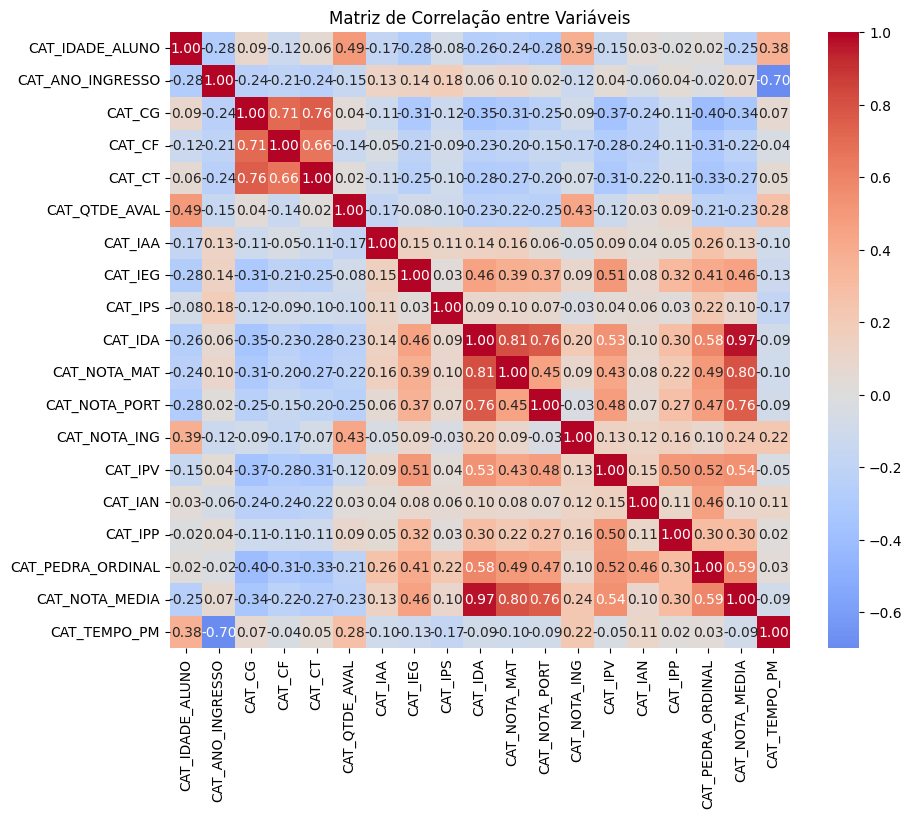

,feature_1,feature_2,correlation
0,CAT_NOTA_MAT,CAT_IDA,0.812005
1,CAT_NOTA_MEDIA,CAT_IDA,0.969838


In [16]:
#Cria uma lista com as variáveis categorizadas
numeric_cols_cat = ["CAT_" + c for c in numeric_cols if c not in [*vars_fe, *[c for c in numeric_cols if c.endswith("_MISSING")]]]

#Realiza análise de correlação
corr_matrix, high_corr = feature_correlation_analysis(
    df_fe[[*numeric_cols_cat, target_col]],
    numeric_cols_cat
)

#Plota o heatmap da matriz de correlação
plot_correlation_matrix(corr_matrix)

#Tabela de variáveis altamente correlacionadas
high_corr

In [17]:
#Remove as features altamente correlacionadas
features_remove = remove_features_high_correlation(df_fe, numeric_cols_cat)
features_numeric_final = [c for c in numeric_cols_cat if c not in features_remove]

#Verifica alta correlação com a variável alvo
var_correlation_target= correlation_with_target(df_fe, target_col, features_numeric_final)
high_corr_target = (
    var_correlation_target
    .loc[var_correlation_target["correlation"] > 0.9, "feature"]
    .tolist()
)

features_numeric_final = [c for c in features_numeric_final if c not in high_corr_target]

print(f"Features removidas por alta correlação: {features_remove} e {high_corr_target}")
print(f"Features finais: {features_numeric_final}")

Features removidas por alta correlação: {'CAT_IDA'} e ['CAT_IAN']
Features finais: ['CAT_IDADE_ALUNO', 'CAT_ANO_INGRESSO', 'CAT_CG', 'CAT_CF', 'CAT_CT', 'CAT_QTDE_AVAL', 'CAT_IAA', 'CAT_IEG', 'CAT_IPS', 'CAT_NOTA_MAT', 'CAT_NOTA_PORT', 'CAT_NOTA_ING', 'CAT_IPV', 'CAT_IPP', 'CAT_PEDRA_ORDINAL', 'CAT_NOTA_MEDIA', 'CAT_TEMPO_PM']


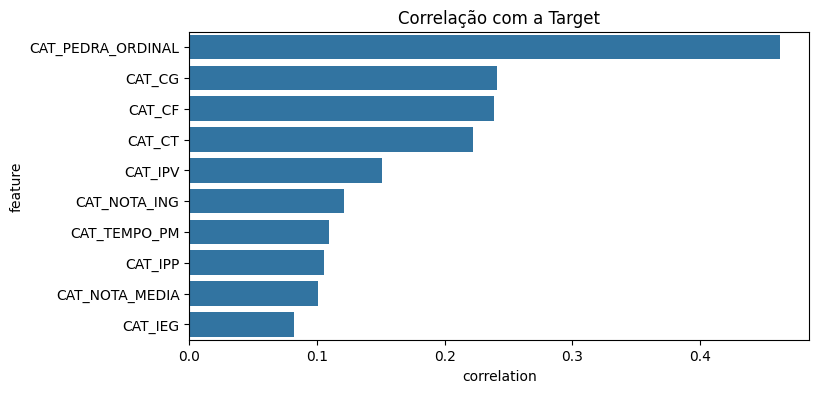

In [18]:
#Plota a correlação das features numéricas com a variável alvo
corr_df = correlation_with_target(
    df=df_fe,
    target_col= target_col,
    numeric_features=features_numeric_final
)

#Função para plotar a correlação das features numéricas com a variável alvo
def plot_correlation_with_target(corr_df, top_n=10):

    plt.figure(figsize=(8,4))

    sns.barplot(
        data=corr_df.head(top_n),
        x="correlation",
        y="feature"
    )

    plt.title("Correlação com a Target")
    plt.show()

#Plota a correlação das features numéricas com a variável alvo
plot_correlation_with_target(corr_df)

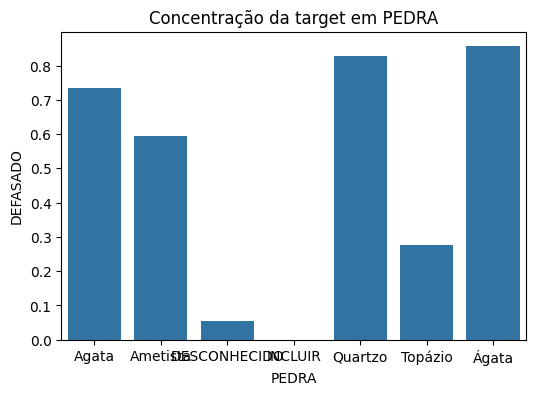

In [19]:
#Análise de concentração da target em variáveis categóricas
conc = categorical_target_concentration(
    df_fe,
    target_col= target_col,
    categorical_features=categorical_cols
)

#Função para plotar a concentração da target em variáveis categóricas
def plot_target_concentration(
    df,
    feature,
    target_col
):

    summary = (
        df.groupby(feature)[target_col]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(6,4))

    sns.barplot(
        data=summary,
        x=feature,
        y=target_col
    )

    plt.title(f"Concentração da target em {feature}")
    plt.show()
    
#Exemplo de plot para a variável PEDRA    
plot_target_concentration(df_fe, "PEDRA", target_col)

In [20]:
categorical_cols_final = [c for c in categorical_cols if c in ['FASE', 'TURMA']]

In [21]:
print(f"Colunas categóricas finais: {categorical_cols_final}")
print(f"Colunas numéricas finais: {features_numeric_final}")

Colunas categóricas finais: ['FASE', 'TURMA']
Colunas numéricas finais: ['CAT_IDADE_ALUNO', 'CAT_ANO_INGRESSO', 'CAT_CG', 'CAT_CF', 'CAT_CT', 'CAT_QTDE_AVAL', 'CAT_IAA', 'CAT_IEG', 'CAT_IPS', 'CAT_NOTA_MAT', 'CAT_NOTA_PORT', 'CAT_NOTA_ING', 'CAT_IPV', 'CAT_IPP', 'CAT_PEDRA_ORDINAL', 'CAT_NOTA_MEDIA', 'CAT_TEMPO_PM']


In [22]:
# Cria DF do modelo
df_model = df_fe.copy()

#Divisão do modelo em treino e teste
model, X_train, X_test, y_train, y_test = train_model(
    df=df_fe,
    numeric_features=features_numeric_final,
    categorical_features=categorical_cols_final,
    target_col=target_col,
    test_year=2024
)

,label,precision,recall,f1-score,support
0,0,0.664122,0.839228,0.741477,622.000000
1,1,0.729730,0.505618,0.597345,534.000000
2,accuracy,0.685121,0.685121,0.685121,0.685121
3,macro avg,0.696926,0.672423,0.669411,1156.000000
4,weighted avg,0.694429,0.685121,0.674897,1156.000000


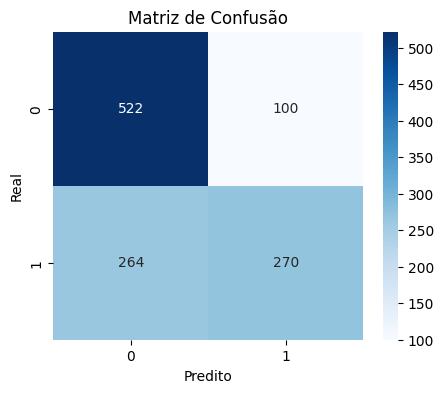

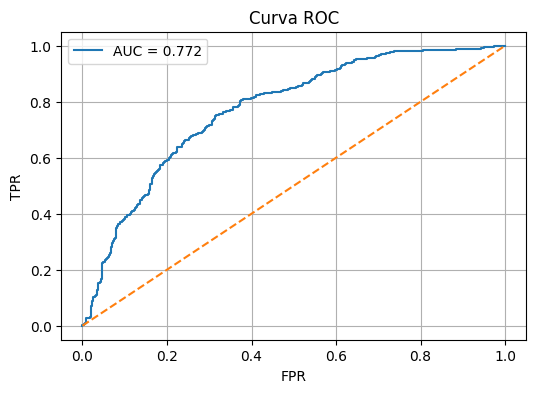

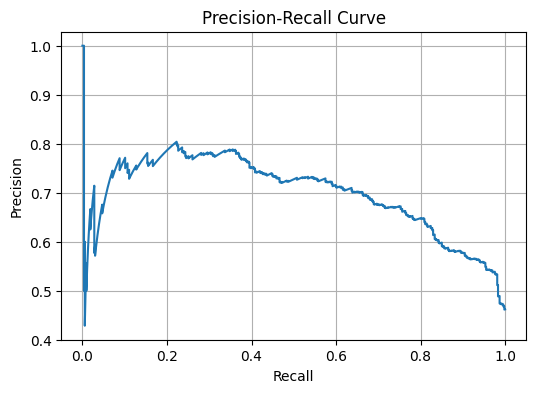

In [23]:
#Métricas do modelo campeão
metrics_df, report_df, metrics_dict = evaluate_model(
    model,
    X_test,
    y_test,
    plot= True
)

metrics_df
report_df

In [24]:
results_df = compare_models(
    df=df_model,
    numeric_features=features_numeric_final,
    categorical_features=categorical_cols_final,
    target_col=target_col,
    test_year=2024
)

results_long = results_df.melt(
    id_vars="model",
    value_vars=["accuracy", "precision", "recall", "f1_score", "roc_auc"],
    var_name="metric",
    value_name="value"
)

results_long

,model,metric,value
0,logistic,accuracy,0.685121
1,random_forest,accuracy,0.746540
2,xgboost,accuracy,0.720588
3,logistic,precision,0.729730
4,random_forest,precision,0.694669
5,xgboost,precision,0.682842
6,logistic,recall,0.505618
7,random_forest,recall,0.805243
8,xgboost,recall,0.737828
9,logistic,f1_score,0.597345


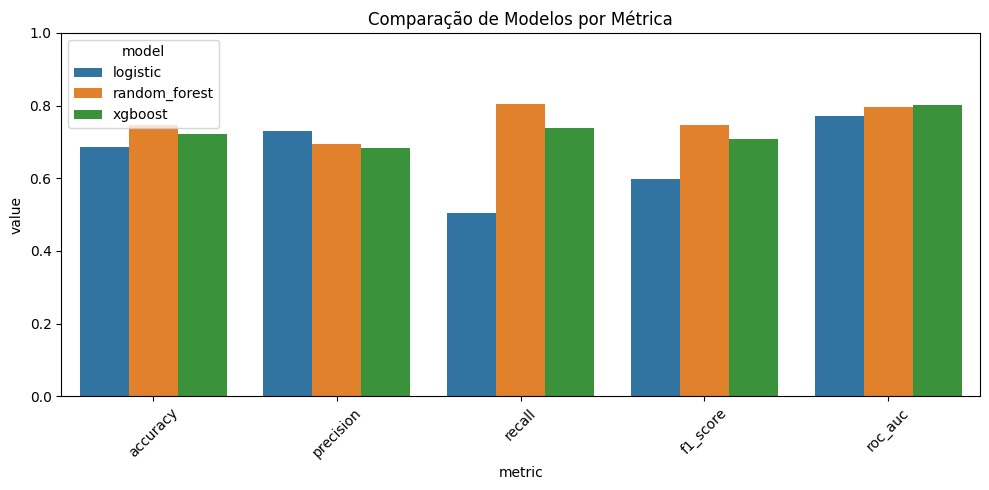

In [25]:
#Gráfico de comparação dos modelos por métrica
plt.figure(figsize=(10, 5))

sns.barplot(
    data=results_long,
    x="metric",
    y="value",
    hue="model"
)

plt.ylim(0, 1)
plt.title("Comparação de Modelos por Métrica")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [26]:
#Treina o modelo campeão para salvar
final_model, X_train_final, X_test_final, y_train_final, y_test_final = train_champion_model(
    df=df_fe,
    numeric_features=features_numeric_final,
    categorical_features=categorical_cols_final,
    target_col=target_col,
    test_year=2024
)

In [28]:
# Cria diretórios
model_dir = Path("../app/model")
model_dir.mkdir(exist_ok=True)

artifacts_dir = Path("../artifacts")
artifacts_dir.mkdir(exist_ok=True)

reference_dir = Path("../monitoring")
reference_dir.mkdir(parents=True, exist_ok=True)

# Salva modelo
save_model(model, model_dir / "model_base.joblib")
save_model(final_model, model_dir / "model_champion.joblib")

# Cria datasets
train_df = pd.concat([X_train_final, y_train_final], axis=1)
test_df = pd.concat([X_test_final, y_test_final], axis=1)

# Normaliza tipos
train_df = train_df.convert_dtypes()
test_df = test_df.convert_dtypes()

# -----------------------------
# Salva PARQUET (artifacts)
# -----------------------------
train_df.to_parquet(
    artifacts_dir / "train_data.parquet",
    engine="pyarrow"
)

test_df.to_parquet(
    artifacts_dir / "test_data.parquet",
    engine="pyarrow"
)

# -----------------------------
# Salva CSV (monitoring/reference)
# -----------------------------
train_df.to_csv(
    reference_dir / "reference.csv",
    index=False
)
